<a href="https://colab.research.google.com/github/rirfan3689/CSCI323-Spam-Detection/blob/main/notebooks/08_spamassassin_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # Upload spam_assassin.csv

df = pd.read_csv('spam_assassin.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Saving spam_assassin.csv to spam_assassin.csv
Shape: (5796, 2)
Columns: ['text', 'target']


,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0


In [2]:
print("Dataset Info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5796 entries, 0 to 5795
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5796 non-null   object
 1   target  5796 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 90.7+ KB
None

Missing values:
text      0
target    0
dtype: int64

Duplicate rows: 467


In [3]:
# Rename for consistency with UCI
df.columns = ['message', 'label']
df['label'] = df['label'].map({0: 'ham', 1: 'spam'})

print("Label Distribution:")
print(df['label'].value_counts())
print("\nHam percentage:", round(df[df['label']=='ham'].shape[0] / df.shape[0] * 100, 2), "%")
print("Spam percentage:", round(df[df['label']=='spam'].shape[0] / df.shape[0] * 100, 2), "%")

Label Distribution:
label
ham     3900
spam    1896
Name: count, dtype: int64

Ham percentage: 67.29 %
Spam percentage: 32.71 %


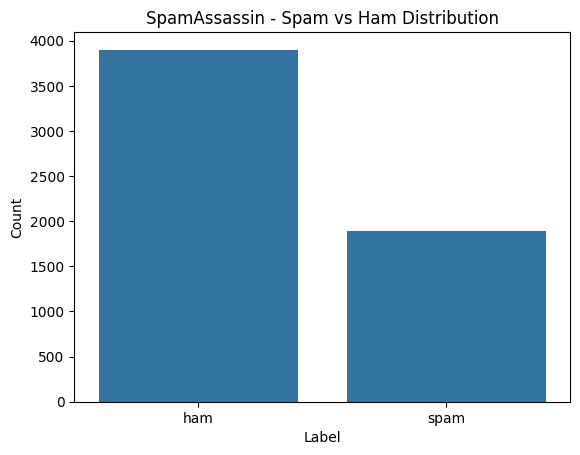

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='label', data=df)
plt.title('SpamAssassin - Spam vs Ham Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.savefig('sa_class_distribution.png')
plt.show()

In [5]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)
print("Duplicate rows remaining:", df.duplicated().sum())

Shape after removing duplicates: (5329, 2)
Duplicate rows remaining: 0


        count         mean          std    min      25%     50%      75%  \
label                                                                      
ham    3638.0  3461.003573  3173.399352  362.0  2400.25  3183.5  4054.25   
spam   1691.0  5677.007096  9466.602237  736.0  2364.00  3809.0  6211.50   

            max  
label            
ham     92469.0  
spam   232305.0  


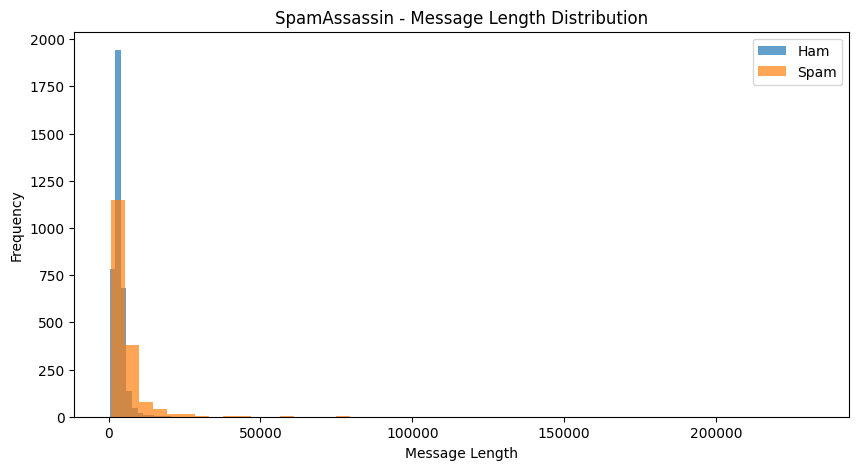

In [6]:
df['message_length'] = df['message'].apply(len)

print(df.groupby('label')['message_length'].describe())

plt.figure(figsize=(10,5))
df[df['label']=='ham']['message_length'].plot(bins=50, kind='hist', label='Ham', alpha=0.7)
df[df['label']=='spam']['message_length'].plot(bins=50, kind='hist', label='Spam', alpha=0.7)
plt.legend()
plt.title('SpamAssassin - Message Length Distribution')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.savefig('sa_message_length_distribution.png')
plt.show()

In [7]:
print("=== Dataset Comparison ===")

# UCI stats - load from saved files
import numpy as np
from scipy.sparse import load_npz

uci_total = 5169
uci_ham_pct = 87.37
uci_spam_pct = 12.63

# SpamAssassin stats - dynamic
sa_total = df.shape[0]
sa_ham_pct = round(df[df['label']=='ham'].shape[0]/df.shape[0]*100, 2)
sa_spam_pct = round(df[df['label']=='spam'].shape[0]/df.shape[0]*100, 2)

print(f"{'Property':<25} {'UCI SMS':<20} {'SpamAssassin':<20}")
print("-" * 65)
print(f"{'Total messages':<25} {str(uci_total):<20} {str(sa_total):<20}")
print(f"{'Ham %':<25} {str(uci_ham_pct)+'%':<20} {str(sa_ham_pct)+'%':<20}")
print(f"{'Spam %':<25} {str(uci_spam_pct)+'%':<20} {str(sa_spam_pct)+'%':<20}")
print(f"{'Avg Ham length':<25} {'71 chars':<20} {str(round(df[df['label']=='ham']['message_length'].mean()))+ ' chars':<20}")
print(f"{'Avg Spam length':<25} {'138 chars':<20} {str(round(df[df['label']=='spam']['message_length'].mean()))+ ' chars':<20}")
print(f"{'Content':<25} {'Body only':<20} {'Full email':<20}")
print(f"{'Domain':<25} {'SMS':<20} {'Email':<20}")

=== Dataset Comparison ===
Property                  UCI SMS              SpamAssassin        
-----------------------------------------------------------------
Total messages            5169                 5329                
Ham %                     87.37%               68.27%              
Spam %                    12.63%               31.73%              
Avg Ham length            71 chars             3461 chars          
Avg Spam length           138 chars            5677 chars          
Content                   Body only            Full email          
Domain                    SMS                  Email               


In [8]:
import json

sa_stats = {
    'total': int(df.shape[0]),
    'ham_count': int(df[df['label']=='ham'].shape[0]),
    'spam_count': int(df[df['label']=='spam'].shape[0]),
    'ham_pct': round(df[df['label']=='ham'].shape[0]/df.shape[0]*100, 2),
    'spam_pct': round(df[df['label']=='spam'].shape[0]/df.shape[0]*100, 2),
    'avg_ham_length': round(df[df['label']=='ham']['message_length'].mean()),
    'avg_spam_length': round(df[df['label']=='spam']['message_length'].mean()),
    'html_tags': 'High',
    'headers': 'High',
    'content': 'Full email',
    'domain': 'Email'
}

with open('sa_stats.json', 'w') as f:
    json.dump(sa_stats, f)

print("SA stats saved!")
print(sa_stats)

SA stats saved!
{'total': 5329, 'ham_count': 3638, 'spam_count': 1691, 'ham_pct': 68.27, 'spam_pct': 31.73, 'avg_ham_length': 3461, 'avg_spam_length': 5677, 'html_tags': 'High', 'headers': 'High', 'content': 'Full email', 'domain': 'Email'}
